# §2.3 Augment TAZ data

Most of the figure creation for this section of the paper happens in QGIS; here we convert the California TAZs into a geographic polygon format for use there (restricted to California to save memory). We also produce the substation territory–area distribution (appendix Figure A.10), which motivates the TAZ-based spatial aggregation.

**Generates:** Figure 3a (SF Bay Area TAZ map, assembled in QGIS from an exported GeoPackage) and appendix Figure A.10 (substation territory–area distribution).

## Load modules

In [1]:
import numpy as np
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from laurel.utils.geo import METERS_PER_MILE
from laurel.utils.h3 import H3_CRS, add_geometries, cells_to_region_polygons

## Set global variables

In [2]:
AREA_CRS = "EPSG:5070" # Conus Albers, in units of meters

## Load data

In [3]:
%reload_ext kedro.ipython
%reload_kedro --params=data_dir=/scratch/users/passow/laurel/data --env=scenario_builders/sense_manage

[06/11/26 09:10:41] INFO     Using                                                                  ]8;id=35210;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=570137;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/fr                
                             amework/project/rich_logging.yml' as logging configuration.                           

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=960452;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=4786;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=243941;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=998366;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=785180;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=718213;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:10:44] INFO     Kedro project LAUREL                                                   ]8;id=345876;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=931388;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

...

                    INFO     Registered line magic 'run_viz'                                        ]8;id=516998;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=540212;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=471928;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=295845;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:10:46] INFO     Kedro project LAUREL                                                   ]8;id=775849;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=806163;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=134919;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=295568;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=970857;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=330503;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [4]:
hexes = catalog.load("hex_cluster_corresp")
hexes = hexes.dropna(subset=["substation_id"])
hexes["substation_id"] = hexes["substation_id"].astype(int)

                    INFO     Loading data from hex_cluster_corresp (FeatherDataset)...         ]8;id=930539;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=514007;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

## Spatialize hexes

Converts H3 hex identifiers to polygon geometries and exports a GeoPackage of California TAZs with their freight activity class assignments, used in QGIS to produce **Figure 3a** — a map of H3 hexagonal TAZs in the SF Bay Area colored by freight activity class.

In [5]:
hexes_ca = hexes.loc[hexes["state_code"] == "CA"]
hexes_ca_geo = add_geometries(hexes_ca, hex_col="hex_id", geom_type="polygon")

In [6]:
catalog.save("example_tazs", hexes_ca_geo)

[06/11/26 09:11:05] INFO     Saving data to example_tazs (GeoPackageDataset)...                ]8;id=741513;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=429893;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

## Figure A.10: Substation territory area distribution

Generates **Figure A.10** in the appendix. ECDF of substation territory areas (square miles), computed from the H3 hex cells assigned to each of the ~52,000 modeled U.S. substations. Motivates the TAZ-based spatial aggregation approach by showing the wide range of territory sizes.

In [7]:
sub_areas = cells_to_region_polygons(
    corresp=hexes.reset_index(),
    region_col="substation_id",
    hex_col="hex_id",
)

In [8]:
sub_areas = sub_areas.to_crs(AREA_CRS)

In [9]:
sub_areas["square_miles"] = sub_areas.area / (METERS_PER_MILE ** 2)
sub_areas["centroid"] = sub_areas.centroid.to_crs(H3_CRS)

[06/11/26 09:12:10] INFO     Saving data to substation_area_distribution                       ]8;id=605528;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=188618;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (MatplotlibDataset)...                                                                

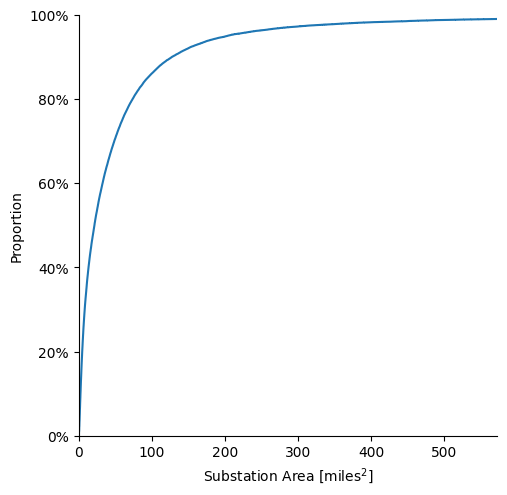

In [10]:
g = sns.displot(data=sub_areas, x="square_miles", kind="ecdf", stat="proportion")
g = g.set_axis_labels(x_var=r"Substation Area [$\mathregular{miles^2}$]", y_var="Proportion")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlim(left=0, right=np.quantile(sub_areas["square_miles"], q=0.99))

catalog.save("substation_area_distribution", g.figure)
g.figure